# Convex and concave one-dimensional assignment costs

This notebook generates `fig:matching-1d-convex-concave-costs`.  For convex costs on the line, sorting gives the optimal matching.  For concave distance profiles, the ordered structure is still useful, but the optimal assignment favors longer crossing exchanges.  The figure compares both regimes on a small Gaussian-to-Gaussian example and on a denser two-component to three-component Gaussian-mixture example.


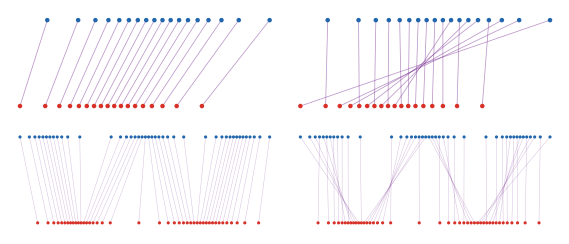

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.stats import norm

from figure_style import (
    RED, BLUE, VIOLET, DIRAC_MARKER_SIZE,
    figure_dir, save_pdf, setup_matplotlib,
)

setup_matplotlib()

OUT = figure_dir("matching-1d-convex-concave-costs")
THUMB = NOTEBOOK_DIR / "thumbnails" / "matching-1d-convex-concave-costs.png"
THUMB.parent.mkdir(exist_ok=True)


def normalize_pair(x, y):
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    x = 2.0 * (x - lo) / (hi - lo) - 1.0
    y = 2.0 * (y - lo) / (hi - lo) - 1.0
    return x, y


def mixture_ppf(u, weights, means, scales, *, lo=-3.0, hi=3.0, grid_size=12000):
    grid = np.linspace(lo, hi, grid_size)
    cdf = np.zeros_like(grid)
    for w, m, s in zip(weights, means, scales):
        cdf += w * norm.cdf(grid, loc=m, scale=s)
    cdf = np.maximum.accumulate(cdf)
    cdf = (cdf - cdf[0]) / (cdf[-1] - cdf[0])
    return np.interp(u, cdf, grid)


def gaussian_instance(n=18):
    u = (np.arange(n) + 0.5) / n
    x = norm.ppf(u, loc=-0.20, scale=0.45)
    y = norm.ppf(u, loc=0.25, scale=0.55)
    return normalize_pair(x, y)


def mixture_instance(n=42):
    u = (np.arange(n) + 0.5) / n
    x = mixture_ppf(
        u,
        weights=np.array([0.46, 0.54]),
        means=np.array([-0.55, 0.48]),
        scales=np.array([0.16, 0.22]),
    )
    y = mixture_ppf(
        u,
        weights=np.array([0.28, 0.39, 0.33]),
        means=np.array([-0.78, 0.02, 0.76]),
        scales=np.array([0.13, 0.17, 0.14]),
    )
    return normalize_pair(x, y)


def assignment(x, y, power):
    C = np.abs(x[:, None] - y[None, :]) ** power
    row, col = linear_sum_assignment(C)
    sigma = np.empty(len(x), dtype=int)
    sigma[row] = col
    return sigma


def draw_panel(ax, x, y, power):
    sigma = assignment(x, y, power)
    n = len(x)
    top = 0.54
    dot_size = DIRAC_MARKER_SIZE * (0.70 if n <= 20 else 0.34)
    line_width = 0.54 if n <= 20 else 0.31
    line_alpha = 0.52 if n <= 20 else 0.34
    for i, j in enumerate(sigma):
        ax.plot([x[i], y[j]], [0, top], color=VIOLET, lw=line_width, alpha=line_alpha, zorder=1)
    ax.scatter(x, np.zeros(n), s=dot_size, color=RED, edgecolor="none", zorder=3)
    ax.scatter(y, np.full(n, top), s=dot_size, color=BLUE, edgecolor="none", zorder=3)
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-0.07, top + 0.07)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


instances = {
    "gaussian": gaussian_instance(),
    "mixture": mixture_instance(),
}
panels = [
    ("convex", "gaussian", 2.0),
    ("concave", "gaussian", 0.5),
    ("mixture-convex", "mixture", 2.0),
    ("mixture-concave", "mixture", 0.5),
]

for filename, inst, power in panels:
    fig, ax = plt.subplots(figsize=(2.65, 1.02))
    draw_panel(ax, *instances[inst], power)
    save_pdf(fig, OUT / f"{filename}.pdf", pad_inches=0.020)
    plt.close(fig)

fig, axs = plt.subplots(2, 2, figsize=(5.5, 2.25))
for ax, (_, inst, power) in zip(axs.ravel(), panels):
    draw_panel(ax, *instances[inst], power)
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.04, hspace=0.08)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.030)
plt.show()
